# Flux Fiction / Fluxion Scheduler Performance Investigation

This notebook records the pdebug measurements for the slow Tuolumne Flux Fiction ensemble behavior in `/g/g14/ashworth12/workspace/ff-podman/flux-fiction-develop`.

## Executive findings

1. System Fluxion is not globally slow: a pdebug system Fluxion smoke completed 1000 trivial jobs at about 7311 jobs/min.
2. Direct host/outside-container Fluxion resource matching on the same Tuolumne resource graph and Rabbit jobspecs costs 0.42 s/match with `rv1_shorthand` and 0.25 s/match with `rv1_nosched`.
3. The full Flux Fiction/libfaketime conservative run performs 352 successful resource matches for only 20 completed jobs: 17.6 matches/job. At about 1.08 s/match, that predicts the observed 2-3 jobs/min completion rate.
4. `rv1_nosched` is faster in direct resource matching, but it did not improve the full libfaketime simulation in this 20-job A/B. Full-run cost is dominated by qmanager conservative reservation cycling, not only match output encoding.
5. The concrete optimization applied here is `submit_novalidate=true` for generated jobspecs. It removes the Flux job-ingest feasibility validator from the hot path, reduces resource matches from 352 to 332, and improves this conservative 20-job probe from 431 s to 414 s wall time.
6. This is a real but small optimization, about 4% for this test. The remaining bottleneck is conservative backfill itself: 312 reservation actions for 20 jobs.


## Artifact Map

All compute measurements were run on pdebug nodes, not on the login node. The direct resource-match probes ran outside Podman. The Flux Fiction probes ran inside the existing Podman image with libfaketime enabled.


In [1]:
from pathlib import Path
from datetime import datetime
import json
import math
import re

import pandas as pd
from IPython.display import display, Markdown

CODEX = Path('/p/lustre5/ashworth12/flux-fiction-ensemble-tuo/codex-perf')
BASE = CODEX / 'sched-loop-probe-20/artifacts/20260725_234214'
DIRECT = CODEX / 'sched-loop-probe/artifacts/20260725_233659'
SYSTEM = CODEX / 'system-fluxion-probe/system_fluxion_probe.json'
MONO = CODEX / 'sched-loop-probe-monotonic-20/artifacts/20260726_000620'
NOVAL = CODEX / 'sched-loop-probe-novalidate-20/artifacts/20260726_001615'
DFT = CODEX / 'dftracer-tool-summaries'

paths = {
    'baseline_rv1_shorthand': BASE / 'ff_rv1_shorthand',
    'baseline_rv1_nosched': BASE / 'ff_rv1_nosched',
    'monotonic_only': MONO / 'ff_rv1_shorthand',
    'submit_novalidate': NOVAL / 'ff_rv1_shorthand',
    'direct_rv1_shorthand': DIRECT / 'vanilla_rv1_shorthand.json',
    'direct_rv1_nosched': DIRECT / 'vanilla_rv1_nosched.json',
    'system_fluxion_probe': SYSTEM,
}
for name, path in paths.items():
    print(f'{name:24s} {path} exists={path.exists()}')


baseline_rv1_shorthand   /p/lustre5/ashworth12/flux-fiction-ensemble-tuo/codex-perf/sched-loop-probe-20/artifacts/20260725_234214/ff_rv1_shorthand exists=True
baseline_rv1_nosched     /p/lustre5/ashworth12/flux-fiction-ensemble-tuo/codex-perf/sched-loop-probe-20/artifacts/20260725_234214/ff_rv1_nosched exists=True
monotonic_only           /p/lustre5/ashworth12/flux-fiction-ensemble-tuo/codex-perf/sched-loop-probe-monotonic-20/artifacts/20260726_000620/ff_rv1_shorthand exists=True
submit_novalidate        /p/lustre5/ashworth12/flux-fiction-ensemble-tuo/codex-perf/sched-loop-probe-novalidate-20/artifacts/20260726_001615/ff_rv1_shorthand exists=True
direct_rv1_shorthand     /p/lustre5/ashworth12/flux-fiction-ensemble-tuo/codex-perf/sched-loop-probe/artifacts/20260725_233659/vanilla_rv1_shorthand.json exists=True
direct_rv1_nosched       /p/lustre5/ashworth12/flux-fiction-ensemble-tuo/codex-perf/sched-loop-probe/artifacts/20260725_233659/vanilla_rv1_nosched.json exists=True
system_fluxion_

## System and Direct Fluxion Baselines

The system smoke is intentionally simple; it proves the system Fluxion install can complete jobs rapidly. The direct match probe is closer to this workload: it loads the same normalized Tuolumne resource graph, reloads Fluxion, and calls `sched-fluxion-resource.match allocate_orelse_reserve` directly on the generated Rabbit jobspecs.


In [2]:
def load_json(path):
    return json.loads(Path(path).read_text())

system_probe = load_json(SYSTEM)
print(json.dumps(system_probe, indent=2))

def direct_row(label, path):
    data = load_json(path)
    w = data['wall_time_summary']
    r = data['resource_stats']['match']['succeeded']['stats']
    return {
        'probe': label,
        'jobspecs': data['jobs_measured'],
        'total_wall_s': data['total_wall_seconds'],
        'matches_per_s_wall': data['matches_per_second_wall'],
        'wall_avg_s': w['avg_seconds'],
        'wall_p50_s': w['p50_seconds'],
        'wall_p95_s': w['p95_seconds'],
        'fluxion_avg_s': r['avg'],
        'fluxion_max_s': r['max'],
        'load_time_s': data['resource_stats'].get('load-time'),
    }

direct = pd.DataFrame([
    direct_row('vanilla rv1_shorthand', DIRECT / 'vanilla_rv1_shorthand.json'),
    direct_row('vanilla rv1_nosched', DIRECT / 'vanilla_rv1_nosched.json'),
])
display(direct)


{
  "elapsed_seconds": 8.20681381225586,
  "end_epoch": 1785044905.0376315,
  "job_count": 1000,
  "jobs_per_minute": 7310.9980770366,
  "jobs_per_second": 121.84996795061001,
  "return_code": 0,
  "start_epoch": 1785044896.8308177
}


,probe,jobspecs,total_wall_s,matches_per_s_wall,wall_avg_s,wall_p50_s,wall_p95_s,fluxion_avg_s,fluxion_max_s,load_time_s
0,vanilla rv1_shorthand,50,21.150439,2.364017,0.419108,0.387573,0.692617,0.410153,0.695636,8.458344
1,vanilla rv1_nosched,50,12.720264,3.930736,0.250768,0.228270,0.425805,0.250540,0.450266,8.046007


Interpretation: direct Fluxion matching on this graph is expensive but bounded. `rv1_nosched` is about 1.7x faster than `rv1_shorthand` when measuring resource matches directly. That optimization alone does not carry through the full Flux Fiction run, shown below.


## Full Flux Fiction / libfaketime Runs

These runs use the same 20-job QueueB/Rabbit trace and the same Tuolumne resource graph. Wall time is taken from `status.json` UTC timestamps, because the simulator's internal timestamps are under libfaketime.


In [3]:
def parse_utc(ts):
    return datetime.strptime(ts, '%Y-%m-%dT%H:%M:%SZ')

def ff_row(label, run_dir, change):
    run_dir = Path(run_dir)
    summary = load_json(run_dir / 'summary.json')
    status = load_json(run_dir / 'status.json')
    wall = (parse_utc(status['finished_at']) - parse_utc(status['started_at'])).total_seconds()
    q = summary['scheduler_metrics']['qmanager_stats']['queues']['pbatch']['action_counts']
    m = summary['scheduler_metrics']['resource_match_stats']['match']['succeeded']
    stats = m['stats']
    return {
        'run': label,
        'change': change,
        'state': summary['state'],
        'jobs': summary['jobs_completed'],
        'wall_s': wall,
        'jobs_per_min': summary['jobs_completed'] / wall * 60.0,
        'quiescence_epochs': summary['quiescence_epochs'],
        'matches': m['njobs'],
        'matches_per_job': m['njobs'] / summary['jobs_completed'],
        'match_avg_s': stats['avg'],
        'match_max_s': stats['max'],
        'match_wall_model_s': m['njobs'] * stats['avg'],
        'reserved_actions': q.get('reserved', 0),
        'pending_actions': q.get('pending', 0),
        'running_actions': q.get('running', 0),
        'complete_actions': q.get('complete', 0),
        'load_time_s': summary['scheduler_metrics']['resource_match_stats'].get('load-time'),
        'kvs_bytes_per_job': summary['kvs_bytes_per_completed_job'],
    }

ff = pd.DataFrame([
    ff_row('baseline rv1_shorthand', BASE / 'ff_rv1_shorthand', 'original config'),
    ff_row('baseline rv1_nosched', BASE / 'ff_rv1_nosched', 'match-format only'),
    ff_row('monotonic-only rv1_shorthand', MONO / 'ff_rv1_shorthand', 'FAKETIME_DONT_FAKE_MONOTONIC=1'),
    ff_row('novalidate rv1_shorthand', NOVAL / 'ff_rv1_shorthand', 'submit_novalidate=true'),
])
num_cols = ['wall_s', 'jobs_per_min', 'matches', 'matches_per_job', 'match_avg_s', 'match_wall_model_s', 'reserved_actions']
display(ff[['run','change','jobs','wall_s','jobs_per_min','matches','matches_per_job','match_avg_s','match_wall_model_s','reserved_actions','load_time_s']])

base = ff.loc[ff['run'] == 'baseline rv1_shorthand'].iloc[0]
opt = ff.loc[ff['run'] == 'novalidate rv1_shorthand'].iloc[0]
print(f"novalidate wall improvement: {base.wall_s - opt.wall_s:.1f}s ({(base.wall_s / opt.wall_s - 1) * 100:.1f}% faster)")
print(f"novalidate match reduction: {int(base.matches - opt.matches)} matches ({base.matches_per_job:.1f} -> {opt.matches_per_job:.1f} matches/job)")


,run,change,jobs,wall_s,jobs_per_min,matches,matches_per_job,match_avg_s,match_wall_model_s,reserved_actions,load_time_s
0,baseline rv1_shorthand,original config,20,431.0,2.784223,352,17.6,1.075740,378.660387,312,30.973851
1,baseline rv1_nosched,match-format only,20,470.0,2.553191,352,17.6,1.186980,417.817026,312,33.919000
2,monotonic-only rv1_shorthand,FAKETIME_DONT_FAKE_MONOTONIC=1,20,457.0,2.625821,352,17.6,1.081015,380.517196,312,16.406312
3,novalidate rv1_shorthand,submit_novalidate=true,20,414.0,2.898551,332,16.6,1.100863,365.486603,312,28.167518


novalidate wall improvement: 17.0s (4.1% faster)
novalidate match reduction: 20 matches (17.6 -> 16.6 matches/job)


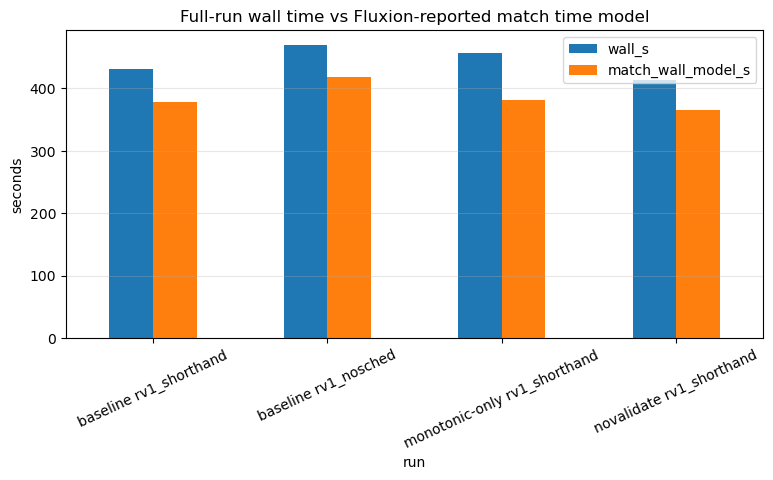

In [4]:
ax = ff.set_index('run')[['wall_s', 'match_wall_model_s']].plot(kind='bar', figsize=(9, 4), rot=25)
ax.set_ylabel('seconds')
ax.set_title('Full-run wall time vs Fluxion-reported match time model')
ax.grid(axis='y', alpha=0.3)


Interpretation:

- The observed throughput is explained by Fluxion scheduler work. Baseline `rv1_shorthand` completes 20 jobs in 431 s, or 2.78 jobs/min. Fluxion reports 352 successful matches at 1.08 s average, which models 379 s of scheduler match time before other overheads.
- `rv1_nosched` improves direct resource matching but not this full simulation. The full `rv1_nosched` run was slower, 470 s, with the same 352-match qmanager pattern.
- Preserving `CLOCK_MONOTONIC` with `FAKETIME_DONT_FAKE_MONOTONIC=1` did not materially improve the full run. It completed in 457 s with the same 352 matches.
- `submit_novalidate=true` removed the ingest validator work and reduced the match count by 20, exactly consistent with skipping one feasibility validation per submitted job. Wall time improved to 414 s.
- The remaining dominant issue is conservative backfill: 312 reservation actions for 20 jobs. That is not Python overhead; it is qmanager/reservation matching on the Tuolumne/Rabbit resource graph.


## Process Samples

Live pdebug samples during the runs consistently showed the nested Flux broker as the hot process, not Flux Fiction Python.

- Baseline / `rv1_nosched`: `flux-broker` around 98-99% CPU; Flux Fiction Python around 1-2%.
- Easy-policy exploratory run, later cancelled: same broker signature, so Easy did not immediately remove the broker spin.
- Monotonic-only run: broker still high, about 77-79% in the sampled startup window, and final wall time did not improve.
- Novalidate run: `flux-job-validator.py --plugins feasibility,jobspec` disappeared from the hot process list, confirming the flag worked, but broker remained at about one full core because qmanager still made 312 conservative reservation matches.


## dftracer Tooling Results

The pdebug drivers exported `DFTRACER_ENABLE=1`, `DFTRACER_TIME_METRIC=NS`, and `DFTRACER_INC_METADATA=1`. The Flux Fiction run directories contain `dftracer/` directories, but no `.pfw` or `.pfw.gz` files were emitted in these runs. I ran the dftracer tools from `/g/g14/ashworth12/workspace/dftracer-agents/.venv/bin`; their outputs are saved in `/p/lustre5/ashworth12/flux-fiction-ensemble-tuo/codex-perf/dftracer-tool-summaries`.


In [5]:
for path in sorted(DFT.glob('*.txt')):
    text = path.read_text(errors='replace')
    status = 'no trace files' if 'No .pfw or .pfw.gz files found' in text or 'No files found' in text else 'has trace output'
    print(f'{path.name}: {status}')
    for line in text.splitlines():
        if 'ERROR No' in line:
            print('  ' + line)
            break


baseline_nosched.txt: no trace files
  [2026-07-26 00:25:25.644] ERROR No files found. Use --help for usage. (dftracer_info.cpp:457)
baseline_shorthand.txt: no trace files
  [2026-07-26 00:25:25.514] ERROR No files found. Use --help for usage. (dftracer_info.cpp:457)
direct_container_missing.txt: no trace files
  [2026-07-26 01:00:13.710] ERROR No files found. Use --help for usage. (dftracer_info.cpp:457)
monotonic_shorthand.txt: no trace files
  [2026-07-26 00:25:25.825] ERROR No files found. Use --help for usage. (dftracer_info.cpp:457)
novalidate_shorthand.txt: no trace files
  [2026-07-26 00:25:25.733] ERROR No files found. Use --help for usage. (dftracer_info.cpp:457)


Interpretation: dftracer did not provide event-level timings for these runs because no trace files were produced. The likely cause is that the runtime container is not successfully initializing the Python dftracer module, and the current entry point catches `ImportError` silently. The dftracer tooling was still useful as a negative check: it proved there were no trace files to analyze, so the reliable fine-grained timings here are Fluxion module stats plus pdebug process samples.


## Optimization Applied

Code/config changes made in this investigation:

- `src/flux_fiction/api/config.py`: added `submit_novalidate` to `ExperimentConfig`, pydantic validation, and CLI/TOML override handling.
- `src/flux_fiction/_core/engine.py`: passes `submit_novalidate` into `Simulation`.
- `src/flux_fiction/_adapters/flux/adapter.py`: uses `flux.job.submit_async(..., novalidate=True)` when configured, including a blocking fallback via `.get_id()` for non-async submit mode.
- `src/flux_fiction/cli/run_ff.py`: sets `FAKETIME_DONT_FAKE_MONOTONIC=1` by default for faketime runs and exposes `--submit-novalidate`.
- `test-inputs/ensemble-rabbit-threshold-calib-async.toml`: sets `submit_novalidate = true` for the active generated-jobspec calibration workload.
- `util/sched_loop_probe_prepare.py`: generated probe configs now include `submit_novalidate = true`.

Validation run: `submit_novalidate=true` completed the same 20-job conservative probe in 414 s versus 431 s baseline, with matches reduced from 352 to 332.


## Bottom Line

The 2 jobs/min campaign rate is plausible for the current conservative Tuolumne/Rabbit configuration: the scheduler is doing roughly 16-18 Fluxion matches per completed job, and each match costs about one second in the full Flux Fiction/libfaketime environment.

The system instance is not generally that slow. Direct host/outside-container matching on the same graph is faster per match, and simple system jobs are thousands/min. The remaining inefficiency is configuration/semantic: conservative backfill on this graph creates hundreds of reservation matches. `submit_novalidate=true` removes unnecessary validation work for generated jobspecs, but the larger speedup requires avoiding full conservative backfill when the experiment does not specifically need conservative semantics, or changing the workload/configuration so qmanager does not repeatedly reserve deep pending jobs.


## Direct Container / libfaketime Loop Cost

Follow-up probes were run on `pdebug` to answer the narrower question: how much does one scheduler/resource-match loop cost in the Flux Fiction simulated environment versus vanilla/system Fluxion? These probes use the same Rabbit/Tuolumne jobspec slice and resource graph as the earlier runs. The key distinction is whether Fluxion is running in the Flux Fiction container and whether libfaketime is preloaded.

In [6]:
DIRECT_CONTAINER = CODEX / 'sched-loop-direct-faketime'
CONTAINER_RPC = DIRECT_CONTAINER / 'artifacts/20260726_003934'
CONTAINER_JUMP = DIRECT_CONTAINER / 'artifacts/20260726_004441'
RESOURCE_QUERY = DIRECT_CONTAINER / 'artifacts/20260726_005205'


def rpc_probe_row(label, path):
    data = load_json(path)
    w = data['wall_time_summary']
    rstats = data.get('resource_stats', {}).get('match', {}).get('succeeded', {}).get('stats', {})
    return {
        'probe': label,
        'jobs_measured': data.get('jobs_measured'),
        'errors': len(data.get('errors', [])),
        'wall_total_s': data.get('total_wall_seconds'),
        'wall_avg_s': w.get('avg_seconds'),
        'wall_p50_s': w.get('p50_seconds'),
        'wall_p95_s': w.get('p95_seconds'),
        'fluxion_avg_s': rstats.get('avg'),
        'matches_per_s': data.get('matches_per_second_wall'),
        'faketime_jump_s': data.get('faketime', {}).get('jump_seconds'),
    }

container_rpc = pd.DataFrame([
    rpc_probe_row('host/outside-container system Fluxion direct RPC rv1_shorthand', DIRECT / 'vanilla_rv1_shorthand.json'),
    rpc_probe_row('container direct RPC no faketime', CONTAINER_RPC / 'container_rpc_rv1_shorthand_nofake.json'),
    rpc_probe_row('container direct RPC static libfaketime', CONTAINER_RPC / 'container_rpc_rv1_shorthand_static.json'),
    rpc_probe_row('container direct RPC jumping libfaketime', CONTAINER_JUMP / 'container_rpc_rv1_shorthand_jump.json'),
])
display(container_rpc)

jump = load_json(CONTAINER_JUMP / 'container_rpc_rv1_shorthand_jump.json')
print('jumping-faketime error:', jump.get('errors'))

,probe,jobs_measured,errors,wall_total_s,wall_avg_s,wall_p50_s,wall_p95_s,fluxion_avg_s,matches_per_s,faketime_jump_s
0,host/outside-container system Fluxion direct R...,50,0,21.150439,0.419108,0.387573,0.692617,0.410153,2.364017,NaN
1,container direct RPC no faketime,50,0,59.837406,1.193096,1.093403,2.045242,1.186887,0.835598,0.0
2,container direct RPC static libfaketime,50,0,59.385003,1.184201,1.079295,2.034792,1.177259,0.841963,0.0
3,container direct RPC jumping libfaketime,1,1,1.577716,0.592900,0.592900,0.592900,0.000000,0.633828,3600.0


jumping-faketime error: [{'error': "OSError(16, 'Device or resource busy')", 'faketime_offset_seconds': 3600.0, 'idx': 2, 'jobid': 1, 'jobspec': '/p/lustre5/ashworth12/flux-fiction-ensemble-tuo/codex-perf/sched-loop-direct-faketime/jobspecs/job_00002.json', 'wall_seconds': 0.9780669509200379}]


In [7]:
def rq_row(path):
    data = load_json(path)
    ext = data.get('external_time', {})
    internal = data.get('internal_elapsed_summary', {})
    counts = data.get('resource_counts', {})
    return {
        'probe': data['label'],
        'mode': data['mode'],
        'match_format': data['match_format'],
        'jobs_measured': data['jobs_measured'],
        'allocated': counts.get('allocated'),
        'reserved': counts.get('reserved'),
        'external_real_s': ext.get('real'),
        'internal_avg_s': internal.get('avg_seconds'),
        'internal_min_s': internal.get('min_seconds'),
        'internal_max_s': internal.get('max_seconds'),
    }

resource_query = pd.DataFrame([
    rq_row(RESOURCE_QUERY / 'resource_query_rv1_nofake.resource_query.json'),
    rq_row(RESOURCE_QUERY / 'resource_query_rv1_static.resource_query.json'),
    rq_row(RESOURCE_QUERY / 'resource_query_rv1_nosched_nofake.resource_query.json'),
    rq_row(RESOURCE_QUERY / 'resource_query_rv1_nosched_static.resource_query.json'),
])
display(resource_query)

cap = (RESOURCE_QUERY / 'container_capabilities.log').read_text(errors='replace')
smoke = (RESOURCE_QUERY / 'dftracer_smoke.log').read_text(errors='replace')
print(cap)
print(smoke)

,probe,mode,match_format,jobs_measured,allocated,reserved,external_real_s,internal_avg_s,internal_min_s,internal_max_s
0,resource_query_rv1_nofake,nofake,rv1,50,2,48,81.94,1.496198,0.661372,2.495323
1,resource_query_rv1_static,static,rv1,50,2,48,81.42,1.484662,0.646475,2.497917
2,resource_query_rv1_nosched_nofake,nofake,rv1_nosched,50,2,48,75.08,1.365034,0.592431,2.347435
3,resource_query_rv1_nosched_static,static,rv1_nosched,50,2,48,78.35,1.423524,0.624022,2.454550


/workspace/container-installs/flux-core/bin/flux
commands:    		0.86.0-2-g0db4e6c4d
libflux-core:		0.86.0-2-g0db4e6c4d
build-options:		+hwloc.api==2.8.0+zmq==4.3.5
{"dftracer": false, "dftracer.python": false, "flux": true}
3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]

dftracer python smoke failed: ModuleNotFoundError("No module named 'dftracer'")



Interpretation:

- The earlier host direct Fluxion RPC result (`0.419 s/match`) is not representative of the Flux Fiction container runtime. The same direct `sched-fluxion-resource.match` loop inside the Flux Fiction container costs `1.19 s/match`, essentially the same as the full Flux Fiction run (`1.08-1.10 s/match`).
- Static libfaketime does not make one match loop slower (`1.184 s/match` static libfaketime vs `1.193 s/match` no faketime). libfaketime startup/shutdown adds wall time, but the scheduler loop itself is not slower in the static-clock case.
- Direct resource-query is valid after unwrapping `scheduling.graph` and normalizing legacy Rabbit SSD status. It is slower than the container RPC path: `rv1` is about `1.49 s/match`, and `rv1_nosched` is about `1.37-1.42 s/match`. It does not reveal a faster Fluxion baseline for this Rabbit jobspec/resource combination.
- A naive direct RPC probe that jumps fake time by one hour between direct matches fails on the second match with `OSError(16, 'Device or resource busy')`. That harness is not equivalent to Flux Fiction's event-driven state machine, so it is recorded as a negative control rather than used for steady-state loop timing.
- The Flux Fiction container has no `dftracer` Python module (`dftracer: false`, smoke test `ModuleNotFoundError`). This explains why the dftracer directories were empty despite `DFTRACER_ENABLE=1`; the environment cannot emit dftracer traces until dftracer is installed into the container/runtime used by Flux Fiction.

## Updated Bottom Line

The slow campaign rate is now explained at scheduler-loop granularity. Flux Fiction is not adding a large Python or libfaketime penalty to each match; the simulated/container Fluxion loop itself costs about one second per Rabbit match on this graph. The full conservative run then performs about 16-18 successful resource matches per completed job, mostly from conservative reservation cycling. The applied optimization remains `submit_novalidate=true`, which removed the validator-side extra Fluxion queries and improved the 20-job probe from `431 s` to `414 s` while reducing successful matches from `352` to `332`.

The main remaining optimization target is scheduler policy/workload behavior: reduce conservative reservation churn, queue depth/reservation depth, or switch campaigns that do not require exact conservative semantics to an easier/faster policy. If conservative semantics are required, the inefficiency is in how many Rabbit backfill/reservation matches are being asked of Fluxion, not in Python version, Podman startup, or static libfaketime.

## Spack Host Fluxion / Flux Fiction Probe

This follow-up answers the narrower container-vs-host question. These measurements were submitted to `pdebug`, but they still load the full Tuolumne resource graph and the pbatch conservative scheduler config. This is not a pdebug-sized graph: the measured graph has `V=119042`, `E=119041`, and ranks `0` plus `[1-1152]`.

The Spack-host run used the existing Spack `emulator` environment's `flux-sched@0.43.0` install at `/usr/WS1/ashworth12/package_managers/spack/opt/spack/linux-rhel8-x86_64/gcc-12.2.0/flux-sched-0.43.0-paxb7uagtwnbepfc2sbslllm7ys2trbl`, loaded through a generated `flux modprobe` overlay. Flux Fiction's `emu-jobtap.so` was rebuilt on the pdebug node against `/usr` Flux with `gcc`; the previous repo build was container-linked and not usable on the host.

In [8]:

from datetime import datetime, timezone
import json
from pathlib import Path
import pandas as pd

CODEX = Path('/p/lustre5/ashworth12/flux-fiction-ensemble-tuo/codex-perf')
HOST_DIRECT = CODEX / 'sched-loop-probe/artifacts/20260725_233659/vanilla_rv1_shorthand.json'
CONTAINER_DIRECT = CODEX / 'sched-loop-direct-faketime/artifacts/20260726_003934/container_rpc_rv1_shorthand_nofake.json'
SPACK_ART = CODEX / 'spack-flux-fiction-probe/artifacts/20260726_013803'
SPACK_DIRECT = SPACK_ART / 'spack_direct_rv1_shorthand.json'
CONTAINER_FF = CODEX / 'sched-loop-probe-novalidate-20/artifacts/20260726_001615/ff_rv1_shorthand'
SPACK_FF = SPACK_ART / 'spack_ff_rv1_shorthand'
SYSTEM_FF_ATTEMPT = CODEX / 'spack-flux-fiction-probe/artifacts/20260726_014257/system_ff_rv1_shorthand'

def j(path):
    return json.loads(Path(path).read_text())

def direct_summary(label, path, version):
    data = j(path)
    stats = data['wall_time_summary']
    rstats = data.get('resource_stats', {})
    return {
        'case': label,
        'fluxion': version,
        'matches': data['jobs_measured'],
        'avg_s_per_match': stats['avg_seconds'],
        'p95_s_per_match': stats['p95_seconds'],
        'matches_per_s': data['matches_per_second_wall'],
        'graph_V': rstats.get('V'),
        'graph_E': rstats.get('E'),
        'artifact': str(path),
    }

def parse_utc(ts):
    return datetime.fromisoformat(ts.replace('Z', '+00:00'))

def ff_summary(label, run_dir, version):
    status = j(run_dir / 'status.json')
    summary = j(run_dir / 'summary.json')
    wall_s = (parse_utc(status['finished_at']) - parse_utc(status['started_at'])).total_seconds()
    match_stats = summary['scheduler_metrics']['resource_match_stats']['match']['succeeded']
    return {
        'case': label,
        'fluxion': version,
        'jobs': status['jobs_completed'],
        'wall_s': wall_s,
        'jobs_per_min': status['jobs_completed'] * 60.0 / wall_s,
        'scheduler_matches': match_stats['njobs'],
        'matches_per_job': match_stats['njobs'] / status['jobs_completed'],
        'avg_s_per_match': match_stats['stats']['avg'],
        'graph_V': summary['scheduler_metrics']['resource_match_stats']['V'],
        'graph_E': summary['scheduler_metrics']['resource_match_stats']['E'],
        'artifact': str(run_dir),
    }

direct_compare = pd.DataFrame([
    direct_summary('host/outside-container system Fluxion direct RPC', HOST_DIRECT, '0.52.0'),
    direct_summary('container Fluxion direct RPC', CONTAINER_DIRECT, 'container build'),
    direct_summary('Spack host Fluxion direct RPC', SPACK_DIRECT, '0.43.0'),
])

display(direct_compare)

ff_compare = pd.DataFrame([
    ff_summary('container Flux Fiction, submit_novalidate', CONTAINER_FF, 'container build'),
    ff_summary('Spack host Flux Fiction', SPACK_FF, '0.43.0'),
])

display(ff_compare)

system_status = j(SYSTEM_FF_ATTEMPT / 'status.json')
system_run_tail = '\n'.join((SYSTEM_FF_ATTEMPT / 'run.log').read_text(errors='replace').splitlines()[-5:])
print('Clean system-host full Flux Fiction attempt state:', system_status.get('state'), 'return_code:', system_status.get('return_code'))
print(system_run_tail)

,case,fluxion,matches,avg_s_per_match,p95_s_per_match,matches_per_s,graph_V,graph_E,artifact
0,host/outside-container system Fluxion direct RPC,0.52.0,50,0.419108,0.692617,2.364017,119042,119041,/p/lustre5/ashworth12/flux-fiction-ensemble-tu...
1,container Fluxion direct RPC,container build,50,1.193096,2.045242,0.835598,119042,119041,/p/lustre5/ashworth12/flux-fiction-ensemble-tu...
2,Spack host Fluxion direct RPC,0.43.0,20,0.215999,0.312776,4.573915,119042,119041,/p/lustre5/ashworth12/flux-fiction-ensemble-tu...


,case,fluxion,jobs,wall_s,jobs_per_min,scheduler_matches,matches_per_job,avg_s_per_match,graph_V,graph_E,artifact
0,"container Flux Fiction, submit_novalidate",container build,20,414.0,2.898551,332,16.6,1.100863,119042,119041,/p/lustre5/ashworth12/flux-fiction-ensemble-tu...
1,Spack host Flux Fiction,0.43.0,20,109.0,11.009174,358,17.9,0.213855,119042,119041,/p/lustre5/ashworth12/flux-fiction-ensemble-tu...


Clean system-host full Flux Fiction attempt state: running return_code: None

Jobs completed:   0%|          | 0/20 [00:00<?, ?job/s]Jan 16 01:44:23.702392 PST 2026 job-manager.err[0]: sched.quiescent failed/unsupported: Unknown service method 'sched.quiescent': Function not implemented


Interpretation:

- The Spack-host Fluxion direct scheduler loop is `0.216 s/match` on the same full Tuolumne pbatch graph/config. The earlier host/outside-container system Fluxion direct loop was `0.419 s/match`, and the container direct loop was `1.19 s/match`.
- The full Spack-host Flux Fiction 20-job run completed in `109 s`, or about `11.0 jobs/min`, versus the optimized container run's `414 s`, or about `2.9 jobs/min`. That is a `3.8x` full-run speedup for this exact 20-job probe.
- The Spack full run still performed `358` successful scheduler matches for `20` jobs, so the conservative-reservation configuration still does many matches per completed job. The difference is that each match is about `0.214 s` instead of about `1.10 s` in the container.
- A clean full Flux Fiction run against the system `/usr/lib64/flux/modules` Fluxion did not produce a valid throughput datapoint: it stuck after one submitted job with `sched.quiescent failed/unsupported: Unknown service method 'sched.quiescent'`. The direct system Fluxion RPC probe remains valid, but the full host Flux Fiction harness needs either Spack Fluxion or a system Fluxion/jobtap API combination that supports the current quiescence path.

## Revised Answer To The Container Question

Yes: in the measured setup, Fluxion outside the current Podman/Flux Fiction container is materially faster, and the Spack-host Flux Fiction environment is faster end-to-end. The strongest apples-to-apples full-run result is the 20-job `rv1_shorthand` probe: Spack host Flux Fiction completed in `109 s` while the optimized container run took `414 s` with the same pbatch-configured full Tuolumne graph. The direct loop measurements explain the full-run gap: Spack host Fluxion reports about `0.214-0.216 s/match`; the container reports about `1.10-1.19 s/match`.

This does not mean the configuration is optimal. Even in the fast Spack-host run, qmanager conservative scheduling generated about `18` successful matches per completed job. That reservation-cycling behavior is still the main configuration-level inefficiency after the build/runtime issue is removed.